In [1]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

from backtest import *
import concurrent.futures
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from plot import *
import random
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Connect to TradingView
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


In [2]:
# --- Select Stock Universe from Excel File ---
# Load pre-screened stocks from the stock screener output file
# Filter for large-cap stocks (market cap > $10B) to ensure liquidity
def extract_stocks(current_date, index_name, index_dict, period=252, RS=90, all_stocks=True, cap_threshold=10):
    excel_filename = get_excel_filename(current_date, index_name, index_dict, period, RS, all_stocks)
    excel_df = pd.read_excel(excel_filename)
    stocks_df = excel_df.loc[excel_df["Market Cap (B, USD)"] > cap_threshold, ["Stock", "Market Cap (B, USD)"]]
    return stocks_df["Stock"].tolist()

# --- Fetch Price Data ---
# Fetch historical closing prices for all stocks
def fetch_price_data(stocks, current_date):
    # Fetch historical price data for all stocks
    price_data = {}
    for stock in tqdm(stocks, desc="Fetching price data"):
        df = get_df(stock, current_date)
        df = df[df.index <= current_date]
        price_data[stock] = df["Close"]
    return price_data

# --- Weekly Returns Z-Score Analysis ---
# Z-score measures how unusual this week's return is vs historical weekly returns
# High z-score (>2) = unusually strong week, may indicate temporary spike
def compute_weekly_return_zscores(price_data, stocks, period_week_zscore, days_per_week):
    df_prices_weekly = pd.DataFrame({stock: price_data[stock].tail(period_week_zscore + days_per_week) for stock in stocks})
    weekly_prices = df_prices_weekly.iloc[::days_per_week]
    weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()

    mean_return = weekly_returns.mean()
    std_return = weekly_returns.std()
    recent_return = weekly_returns.iloc[-1]
    z_scores = (recent_return - mean_return) / std_return

    return weekly_returns, mean_return, std_return, recent_return, z_scores

# --- Momentum and Volatility Analysis ---
# Momentum: price ratio (recent / year-ago) - measures trend strength over 1 year
# Volatility: standard deviation of daily returns - measures price variability
# Vol-adj Momentum: momentum / volatility - risk-adjusted trend
def calculate_momentum_volatility(price_data, stocks, period_mom_short, period_mom_long, period_vol):
    # Build DataFrame once for vectorized operations
    df_prices = pd.DataFrame({stock: price_data[stock].tail(period_mom_long + 1) for stock in stocks})
    
    # Vectorized momentum calculation: price at -period_mom_short / price at -period_mom_long
    momentum_array = df_prices.iloc[-period_mom_short].values / df_prices.iloc[-period_mom_long].values
    
    # Vectorized volatility calculation: std of daily returns over period_vol
    daily_returns = df_prices.pct_change(fill_method=None).dropna()
    volatility_array = daily_returns.tail(period_vol).std().values
    
    return momentum_array.tolist(), volatility_array.tolist()

# --- Hierarchical Clustering Analysis ---
# Groups stocks by return correlation using Ward's linkage (minimizes within-cluster variance)
def hierarchical_clustering(price_data, stocks, period_pca, num_clusters):
    # Ensure we have at least 2 stocks to cluster
    if len(stocks) < 2:
        return None, np.array([1] * len(stocks))

    # Build the price dataframe
    df_prices_cluster = pd.DataFrame({stock: price_data[stock].tail(period_pca) for stock in stocks})
    
    # Calculate returns
    returns = df_prices_cluster.pct_change(fill_method=None)
    
    # Check if we have enough valid rows to calculate correlation
    # We need at least 2 rows of returns to have a correlation
    if len(returns.dropna(how="all")) < 2:
        print(f"Warning: Not enough data for clustering in this period. Skipping...")
        return None, np.array([1] * len(stocks))

    # Correlation Matrix
    corr_matrix = returns.corr()
    
    # Handle NaNs in the correlation matrix (caused by zero volatility/flat prices)
    corr_matrix = corr_matrix.fillna(0)
    
    # Convert to distance matrix
    dist_matrix = np.sqrt(2 * (1 - corr_matrix))
    
    # Hierarchical clustering
    try:
        # squareform() expects a symmetric matrix with 0s on the diagonal
        condensed_dist = squareform(dist_matrix, checks=False)
        
        if condensed_dist.size == 0:
            raise ValueError("Condensed distance matrix is empty.")
            
        Z = linkage(condensed_dist, method="ward")
        cluster_labels = fcluster(Z, t=num_clusters, criterion="maxclust")
        return Z, cluster_labels
        
    except Exception as e:
        print(f"Clustering failed: {e}")
        # Fallback: Assign everyone to Cluster 1
        return None, np.array([1] * len(stocks))

# --- Combine All Metrics into Single DataFrame ---
def create_combined_dataframe(stocks, cluster_labels, momentum_list, volatility_list, 
                               mean_return, std_return, recent_return, z_scores):
    """
    Consolidate all computed metrics into a single DataFrame for analysis.
    Adds vol-adjusted momentum and ranks stocks by this metric.
    """
    df_combined = pd.DataFrame({
        "Stock": stocks,
        "Cluster": cluster_labels,
        "Momentum": momentum_list,
        "Volatility": volatility_list,
        "Mean Weekly Return (%)": (mean_return * 100).values,
        "Std Weekly Return (%)": (std_return * 100).values,
        "This Week Return (%)": (recent_return * 100).values,
        "Z-Score": z_scores.values
    })
    
    # Vol-adjusted momentum: normalize momentum by volatility for risk-adjusted comparison
    df_combined["Vol-adj Momentum"] = df_combined["Momentum"] / df_combined["Volatility"]
    
    # Sort by vol-adjusted momentum (descending) and create rank index starting from 1
    df_combined = df_combined.sort_values("Vol-adj Momentum", ascending=False).reset_index(drop=True)
    df_combined.index = df_combined.index + 1
    df_combined.index.name = "Rank"
    return df_combined

# --- Dendrogram Visualization ---
def plot_dendrogram(Z, stocks, period_pca):
    """
    Visualize hierarchical clustering structure as a dendrogram.
    Y-axis (distance) shows how dissimilar clusters are when merged.
    """
    plt.figure(figsize=(14, 8))
    dendrogram(Z, labels=stocks, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Hierarchical Clustering of {len(stocks)} Stocks (Past {period_pca} Days)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

# --- Filter and Display Stocks by Cluster ---
# Exclude stocks with z-score > 2 (unusually high recent returns)
# These may be experiencing unsustainable spikes rather than steady momentum
def filter_stocks_by_zscore(df_combined, z_score_threshold=2):
    """Filter stocks and display by cluster."""
    df_filtered = df_combined[df_combined["Z-Score"] <= z_score_threshold]

    print(f"Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= {z_score_threshold}):")
    for cluster_id in sorted(df_filtered["Cluster"].unique()):
        cluster_df = df_filtered[df_filtered["Cluster"] == cluster_id]
        cluster_stocks = cluster_df["Stock"].tolist()
        print(f"Cluster {cluster_id} ({len(cluster_df)} stocks): {', '.join(cluster_stocks)}")
    
    return df_filtered

def select_top_stocks_with_weights(df_combined):
    """
    Select top stock from each cluster and calculate inverse volatility weights.
    Get the highest rank stock from each cluster (already sorted by Vol-adj Momentum).
    """
    top_stocks_per_cluster = df_combined.groupby("Cluster").first().reset_index()
    
    # --- Calculate Inverse Volatility Weights ---
    volatilities = top_stocks_per_cluster["Volatility"].values
    inv_vol = 1 / volatilities
    weights = inv_vol / inv_vol.sum()

    # --- Display Portfolio Allocation ---
    return pd.DataFrame({
        "Cluster": top_stocks_per_cluster["Cluster"],
        "Stock": top_stocks_per_cluster["Stock"],
        "Volatility": volatilities,
        "Weight (%)": weights * 100
    })

In [3]:
# --- Main Monthly Portfolio Construction Function ---
def construct_month_portfolio(current_date, index_name, index_dict, parameters):
    """
    Construct a monthly momentum portfolio based on hierarchical clustering and vol-adjusted momentum.
    """
    # Extract stocks
    stocks = extract_stocks(current_date, index_name, index_dict)
    
    # Fetch price data
    price_data = fetch_price_data(stocks, current_date)
    
    # Weekly returns z-score analysis
    weekly_returns, mean_return, std_return, recent_return, z_scores = compute_weekly_return_zscores(
        price_data, stocks, parameters["period_week_zscore"], parameters["days_per_week"])
    
    # Momentum and volatility calculation
    momentum_list, volatility_list = calculate_momentum_volatility(
        price_data, stocks, parameters["period_mom_short"], parameters["period_mom_long"], parameters["period_vol"])
    
    # Hierarchical clustering
    Z, cluster_labels = hierarchical_clustering(price_data, stocks, parameters["period_pca"], parameters["num_clusters"])
    
    # Create combined DataFrame
    df_combined = create_combined_dataframe(
        stocks, cluster_labels, momentum_list, volatility_list,
        mean_return, std_return, recent_return, z_scores)
    
    # Filter stocks by z-score
    df_filtered = filter_stocks_by_zscore(df_combined)
    
    # Select top stocks with weights
    portfolio_df = select_top_stocks_with_weights(df_filtered)
    
    return portfolio_df

Fetching price data: 100%|██████████| 81/81 [00:01<00:00, 46.42it/s]


,Stock,Cluster,Momentum,Volatility,Mean Weekly Return (%),Std Weekly Return (%),This Week Return (%),Z-Score,Vol-adj Momentum
Rank,,,,,,,,,
1,SAN,2,2.424893,0.014733,1.686726,3.907454,2.370870,0.175087,164.593572
2,PUK,2,1.925560,0.011699,1.395572,3.227198,1.927941,0.164963,164.589953
3,BBVA,2,2.198623,0.016741,1.563450,3.987572,4.492445,0.734531,131.332232
4,MT,3,2.062328,0.015989,1.290501,5.205362,1.016219,-0.052692,128.987835
5,ING,2,1.709125,0.013861,1.272460,3.552245,2.154718,0.248366,123.303452
6,CIB,3,1.987346,0.016459,1.142817,3.688948,1.758950,0.167021,120.743322
7,BCS,2,1.805914,0.015274,1.299169,3.736864,2.253302,0.255330,118.236662
8,DB,2,2.173687,0.018601,1.640565,4.512777,0.075640,-0.346777,116.858637
9,IONS,3,2.305865,0.019753,2.301691,7.435557,-1.751534,-0.545114,116.736625


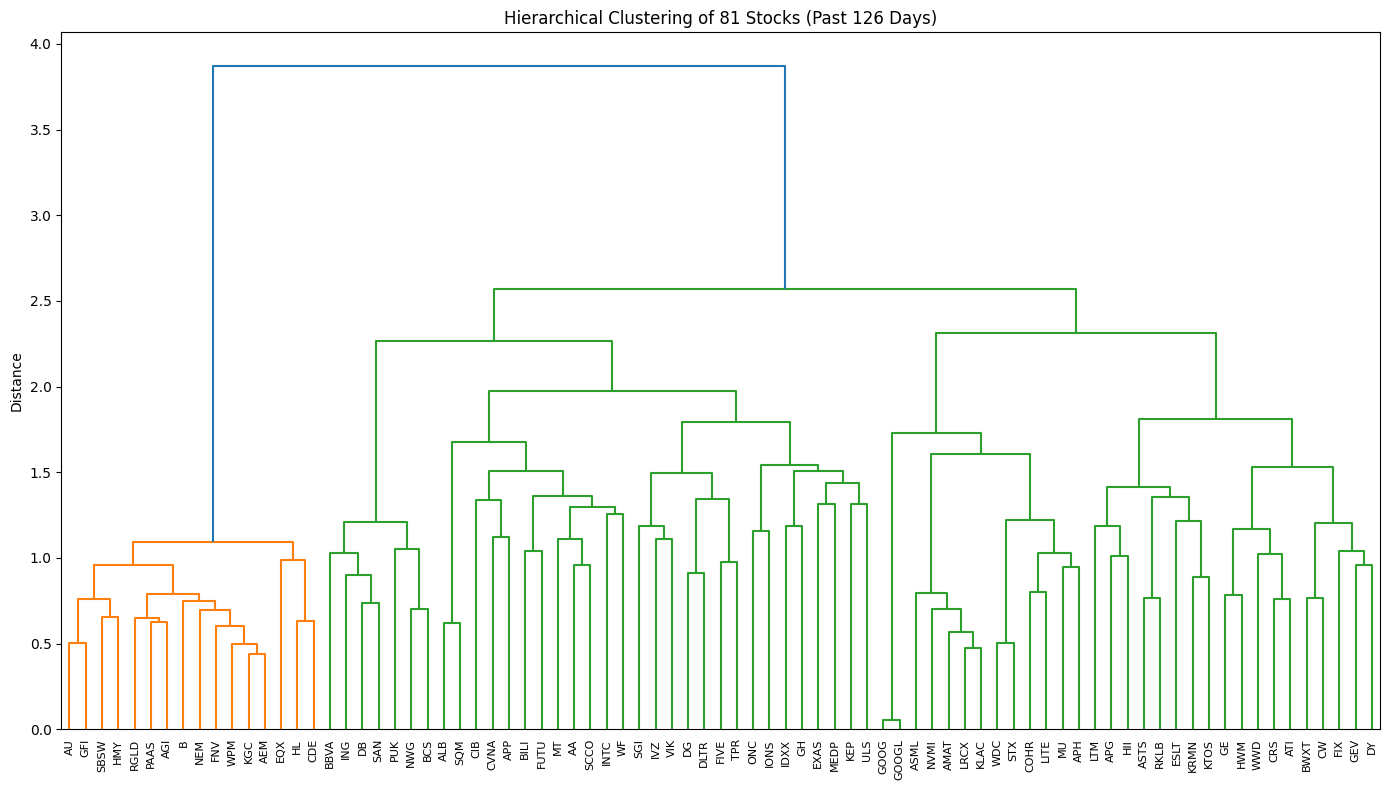

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (16 stocks): AU, B, SBSW, KGC, FNV, GFI, EQX, NEM, AEM, WPM, HL, RGLD, AGI, PAAS, HMY, CDE
Cluster 2 (7 stocks): SAN, PUK, BBVA, ING, BCS, DB, NWG
Cluster 3 (27 stocks): MT, CIB, IONS, WF, FIVE, KEP, IVZ, MEDP, VIK, SGI, TPR, DLTR, ONC, FUTU, IDXX, ULS, SCCO, DG, APP, GH, INTC, BILI, SQM, CVNA, EXAS, ALB, AA
Cluster 4 (12 stocks): GOOG, GOOGL, APH, WDC, KLAC, STX, LRCX, LITE, MU, AMAT, NVMI, COHR
Cluster 5 (18 stocks): LTM, HWM, GE, APG, ESLT, DY, ATI, CW, HII, WWD, BWXT, FIX, KTOS, GEV, ASTS, CRS, RKLB, KRMN


,Cluster,Stock,Volatility,Weight (%)
0,1,AU,0.036082,10.251264
1,2,SAN,0.014733,25.106390
2,3,MT,0.015989,23.134223
3,4,GOOG,0.018150,20.379433
4,5,LTM,0.017506,21.128689


In [4]:
# --- Parameters ---
days_per_week = 5  # Trading days in a week
num_weeks = 52  # Weeks in a year
period_week_zscore = days_per_week * num_weeks  # 1-year lookback for weekly return z-score
period_pca = 126  # 6-month lookback for PCA clustering
period_mom_short = 21  # 1-month lookback for short-term momentum
period_mom_long = 252  # 1-year lookback for long-term momentum
period_vol = 60  # 3-month volatility window
num_clusters = 5  # Number of clusters for hierarchical grouping
parameters = {
    "days_per_week": days_per_week,
    "period_week_zscore": period_week_zscore,
    "period_pca": period_pca,
    "period_mom_short": period_mom_short,
    "period_mom_long": period_mom_long,
    "period_vol": period_vol,
    "num_clusters": num_clusters
}

# --- Extract Stocks ---
stocks = extract_stocks("2026-01-10", index_name, index_dict)

# --- Fetch Price Data ---
price_data = fetch_price_data(stocks, "2026-01-10")

# --- Compute Weekly Return Z-Scores ---
weekly_returns, mean_return, std_return, recent_return, z_scores = compute_weekly_return_zscores(
    price_data, stocks, period_week_zscore, days_per_week
)

# --- Calculate Momentum and Volatility ---
momentum_list, volatility_list = calculate_momentum_volatility(price_data, stocks, period_mom_short, period_mom_long, period_vol)

# --- Hierarchical Clustering Analysis ---
Z, cluster_labels = hierarchical_clustering(price_data, stocks, period_pca, num_clusters)

# --- Create Combined DataFrame ---
df_combined = create_combined_dataframe(
    stocks, cluster_labels, momentum_list, volatility_list,
    mean_return, std_return, recent_return, z_scores
)

# --- Display Results ---
pd.set_option("display.max_rows", None)
display(df_combined)
plot_dendrogram(Z, stocks, period_pca)

# --- Filter Stocks by Z-Score and Display by Cluster ---
filter_stocks_by_zscore(df_combined)
portfolio_df = select_top_stocks_with_weights(df_combined)
display(portfolio_df)

In [5]:
# --- Rebalance dates for monthly portfolio analysis ---
rebalance_dates = [
    "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-05-31",
    "2024-07-01", "2024-08-03", "2024-08-31", "2024-10-03", "2024-11-02", "2024-11-30",
    "2025-01-04", "2025-02-01", "2025-03-01", "2025-04-05", "2025-05-01", "2025-06-03",
    "2025-07-01", "2025-08-01", "2025-09-06", "2025-10-01", "2025-11-01", "2025-12-04", 
    "2026-01-03"
]

In [6]:
# --- Construct Monthly Portfolios ---
monthly_portfolios = {}
for date in rebalance_dates:
    portfolio_df = construct_month_portfolio(date, index_name, index_dict, parameters)
    monthly_portfolios[date] = portfolio_df
    print(f"\nPortfolio for {date}:")
    display(portfolio_df)

Fetching price data: 100%|██████████| 35/35 [00:00<00:00, 53.03it/s]


Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (2 stocks): NVO, JHX
Cluster 2 (4 stocks): TT, PH, HUBB, RACE
Cluster 3 (2 stocks): FCNCA, ERIE
Cluster 4 (17 stocks): META, CMG, MSFT, VRT, UBER, ANET, AMZN, NOW, DECK, INTU, ADBE, CDNS, GOOG, GOOGL, PANW, CRM, DT
Cluster 5 (9 stocks): APP, SAP, MANH, KKR, NU, MELI, ISRG, SMCI, XP

Portfolio for 2024-02-01:


,Cluster,Stock,Volatility,Weight (%)
0,1,NVO,0.015820,20.973893
1,2,TT,0.013253,25.036002
2,3,FCNCA,0.016527,20.077070
3,4,META,0.013985,23.726657
4,5,APP,0.032574,10.186378


Fetching price data: 100%|██████████| 34/34 [00:00<00:00, 57.79it/s]

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (6 stocks): MLM, IR, HWM, MANH, TM, ISRG
Cluster 2 (3 stocks): NVO, ERIE, BAH
Cluster 3 (12 stocks): PCAR, APO, KKR, ARES, RCL, DDOG, UBER, ENTG, APP, CVNA, PSTG, CELH
Cluster 4 (3 stocks): AMZN, DECK, META
Cluster 5 (9 stocks): VRT, NOW, CRM, SAP, CRWD, NVDA, ANET, SMCI, SNPS

Portfolio for 2024-03-01:


...

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (6 stocks): AU, AEM, GFI, NEM, WPM, EQX
Cluster 2 (13 stocks): APH, CIEN, CLS, AVGO, KLAC, WDC, LRCX, TSM, FN, STX, ASML, MU, CRDO
Cluster 3 (10 stocks): MEDP, MT, CAH, SGI, IDXX, ATI, GH, CRS, SQM, EXAS
Cluster 4 (7 stocks): SAN, PUK, BBVA, ING, DB, WF, KEP
Cluster 5 (14 stocks): BSAC, CIB, IONS, ITUB, BBD, ALNY, HOOD, LTM, TPR, DY, GEV, FIX, APP, TEVA

Portfolio for 2025-12-04:


,Cluster,Stock,Volatility,Weight (%)
0,1,AU,0.035557,10.459929
1,2,APH,0.019705,18.874720
2,3,MEDP,0.022767,16.336513
3,4,SAN,0.015575,23.879849
4,5,BSAC,0.012215,30.448989


Fetching price data: 100%|██████████| 75/75 [00:01<00:00, 53.60it/s]

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (15 stocks): AU, B, SBSW, KGC, FNV, EQX, GFI, AEM, NEM, HL, WPM, RGLD, AGI, PAAS, HMY
Cluster 2 (7 stocks): PUK, SAN, BBVA, ING, DB, BCS, NWG
Cluster 3 (16 stocks): BSAC, IONS, CIB, WF, KEP, MT, GH, NTES, CAH, INTC, SCCO, FUTU, SQM, MDB, EXAS, ALB
Cluster 4 (15 stocks): APH, WDC, KLAC, GLW, LRCX, STX, ASML, MU, JBL, LITE, ASX, FN, NVMI, CVNA, COHR
Cluster 5 (21 stocks): HWM, GE, C, LTM, ESLT, DY, ATI, WWD, NRG, TPR, FIVE, DLTR, MTZ, FIX, DG, CRS, GEV, ASTS, FTAI, RKLB, KRMN

Portfolio for 2026-01-03:


,Cluster,Stock,Volatility,Weight (%)
0,1,AU,0.036830,9.338971
1,2,PUK,0.012024,28.605568
2,3,BSAC,0.013042,26.373431
3,4,APH,0.022473,15.305356
4,5,HWM,0.016880,20.376675


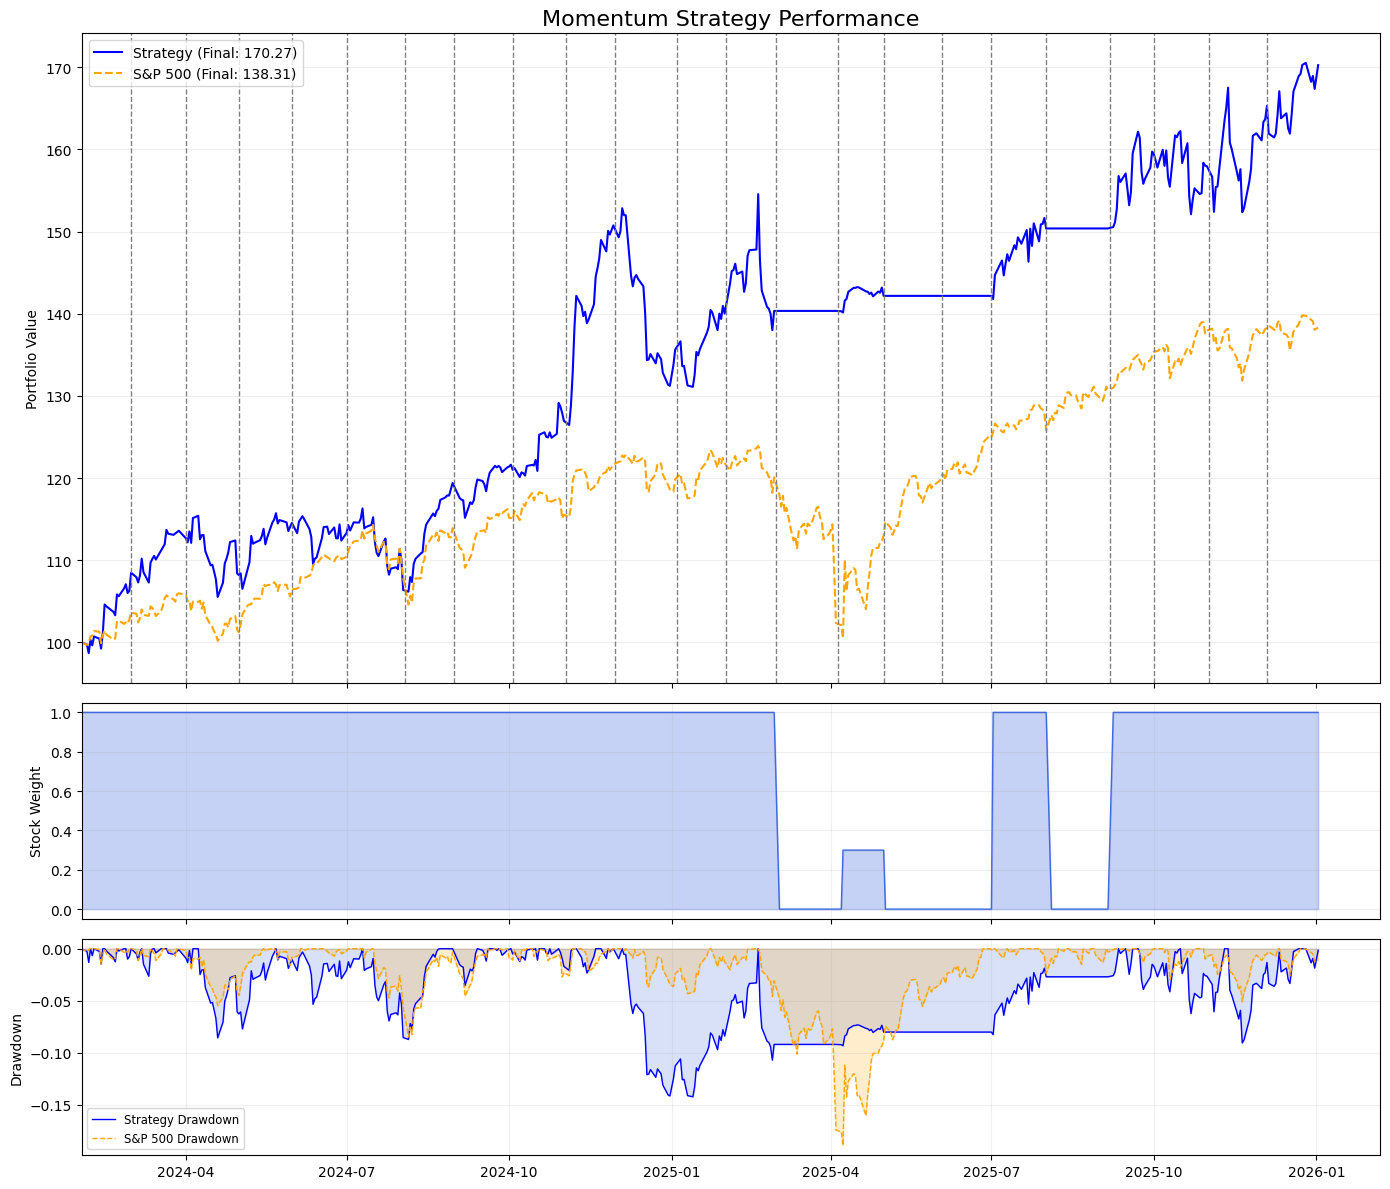

--- Performance Comparison ---
            CAGR Sharpe Sortino Calmar Annualized Vol   Max DD
Strategy  32.01%   1.53    1.92   2.25         19.55%  -14.23%
S&P 500   18.44%   1.14    1.44   0.98         16.14%  -18.90%


In [7]:
# --- Configuration & Initialization ---
# Set the base value to 100 for percentage tracking and define the 0.1% fee
current_capital = 100.0
transaction_fee_rate = 0.001 

equity_curve = []
equity_dates = []
exposure_curve = [] # Track weighting here

# Retrieve the full trading calendar using the S&P 500 as a reference
sp500_df = get_df("^GSPC", current_date)
sp500_df["SMA 200"] = SMA(sp500_df, 200)
mmth_df = get_df("MMTH", current_date, method="tradingview")
mmfi_df = get_df("MMFI", current_date, method="tradingview")
trading_dates = sp500_df.index

# Use the pre-defined sp500_df for the trading calendar and benchmark comparison
trading_dates = sp500_df.index

# --- Portfolio Backtest Loop ---
for i in range(len(rebalance_dates) - 1):
    rebalance_date = rebalance_dates[i]
    next_rebalance_date = rebalance_dates[i + 1]
    signal_date = trading_dates[trading_dates <= rebalance_date][-1]
    
    try:
        buy_date = trading_dates[trading_dates > rebalance_date][0]
        sell_date = trading_dates[trading_dates > next_rebalance_date][0]
    except IndexError:
        break 

    # Detemine exposure level
    current_sp_close = sp500_df["Close"].loc[signal_date]
    current_sp_sma = sp500_df["SMA 200"].loc[signal_date]
    current_mmth = mmth_df["Close"].loc[signal_date]

    # Logic flags
    base_exposure = 0.0 if ((current_sp_close < current_sp_sma) or (current_mmth < 50)) else 1.0

    # Get the portfolio for the current rebalance date
    portfolio = monthly_portfolios[rebalance_date]
    period_dates = trading_dates[(trading_dates >= buy_date) & (trading_dates < sell_date)]
    
    # Pre-calculate daily returns for the portfolio to make the daily loop faster
    daily_returns_list = []
    for _, row in portfolio.iterrows():
        ticker = row["Stock"]
        weight = row["Weight (%)"] / 100
        stock_df = get_df(ticker, sell_date.strftime("%Y-%m-%d"))
        
        if stock_df is not None and buy_date in stock_df.index:
            # First day: Open to Close. Subsequent days: Prev Close to Close.
            prices = stock_df.loc[period_dates, "Close"].reindex(period_dates)
            first_day_ret = prices.iloc[0] / stock_df.loc[buy_date, "Open"]
            other_days_ret = prices / prices.shift(1)
            other_days_ret.iloc[0] = first_day_ret
            daily_returns_list.append(other_days_ret * weight)
        else:
            daily_returns_list.append(pd.Series(1.0 * weight, index=period_dates))

    # Daily return of the full portfolio (100% invested)
    portfolio_daily_returns = pd.concat(daily_returns_list, axis=1).sum(axis=1)

    # --- DAILY EXECUTION LOOP (Handles MMFI Trigger) ---
    active_exposure = base_exposure
    mmfi_triggered = False 
    
    # Apply initial fee if we are starting with exposure > 0
    if active_exposure > 0:
        current_capital *= (1 - (transaction_fee_rate * active_exposure))

    for date in period_dates:
        # Calculate today's growth based on the exposure decided YESTERDAY
        day_return = portfolio_daily_returns.loc[date]
        strategy_day_growth = (day_return * active_exposure) + (1.0 * (1 - active_exposure))
        
        # Update capital and equity curve
        current_capital *= strategy_day_growth
        equity_curve.append(current_capital)
        equity_dates.append(date)
        exposure_curve.append(active_exposure) # Record current weight

        # Check for MMFI trigger TODAY to affect TOMORROW'S open
        current_mmfi = mmfi_df["Close"].loc[date]
        
        if not mmfi_triggered and current_mmfi < 10:
            # Override the logic for the rest of this rebalance period
            mmfi_triggered = True
            
            # Fee for changing exposure
            if active_exposure != 0.3:
                current_capital *= (1 - transaction_fee_rate * abs(active_exposure - 0.3))
            
            active_exposure = 0.3
            # Note: This active_exposure will be used starting the NEXT date in the loop

# --- Benchmark Processing ---
# Create the Portfolio Series
strategy_series = pd.Series(equity_curve, index=equity_dates, name="Strategy")
# Normalize Strategy to 100 at the start so it aligns with the Benchmark
strategy_series = (strategy_series / strategy_series.iloc[0]) * 100
exposure_series = pd.Series(exposure_curve, index=equity_dates)

# Align S&P 500: Filter for the same dates and normalize to 100 at the start
benchmark_series = sp500_df.loc[strategy_series.index, "Close"]
benchmark_series = (benchmark_series / benchmark_series.iloc[0]) * 100
benchmark_series.name = "S&P 500"

# Calculate drawdowns
def get_drawdown(series):
    rolling_max = series.cummax()
    return (series - rolling_max) / rolling_max

strat_dd = get_drawdown(strategy_series)
bench_dd = get_drawdown(benchmark_series)

# --- Performance Metrics Engine ---
def calculate_metrics(series):
    # Calculate daily returns for volatility and risk-adjusted ratios
    returns = series.pct_change().dropna()
    
    # Annualized Return (CAGR)
    total_return = (series.iloc[-1] / series.iloc[0]) - 1
    years = (series.index[-1] - series.index[0]).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1
    
    # Annualized Volatility
    vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio (assuming 0% risk-free rate)
    sharpe = (returns.mean() * 252) / vol
    
    # Sortino Ratio (downside deviation only)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside_vol
    
    # Maximum Drawdown
    rolling_max = series.cummax()
    drawdowns = (series - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    
    # Calmar Ratio
    calmar = cagr / abs(max_dd)
    
    return {
        "CAGR": f"{cagr:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Calmar": f"{calmar:.2f}",
        "Annualized Vol": f"{vol:.2%}",
        "Max DD": f"{max_dd:.2%}"
    }

# Calculate metrics for both
strat_metrics = calculate_metrics(strategy_series)
bench_metrics = calculate_metrics(benchmark_series)

# --- Visualization & Comparison ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})

# Equity curve
ax1.plot(strategy_series, label=f"Strategy (Final: {strategy_series.iloc[-1]:.2f})", color="blue", lw=1.5)
ax1.plot(benchmark_series, label=f"S&P 500 (Final: {benchmark_series.iloc[-1]:.2f})", color="orange", lw=1.5, ls="--")
ax1.set_title("Momentum Strategy Performance", fontsize=16)
ax1.set_ylabel("Portfolio Value")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.2)
ax1.set_xlim(left=strategy_series.index[0])

# Stock exposure
ax2.fill_between(exposure_series.index, exposure_series, color="royalblue", alpha=0.3, label="Stock Exposure")
ax2.plot(exposure_series, color="royalblue", lw=1)
ax2.set_ylabel("Stock Weight")
ax2.grid(True, alpha=0.2)

# Drawdown
ax3.plot(strat_dd, color="blue", lw=1, label="Strategy Drawdown")
ax3.fill_between(strat_dd.index, strat_dd, 0, color="royalblue", alpha=0.2)
ax3.plot(bench_dd, color="orange", lw=1, ls="--", label="S&P 500 Drawdown")
ax3.fill_between(bench_dd.index, bench_dd, 0, color="orange", alpha=0.2)
ax3.set_ylabel("Drawdown")
ax3.legend(loc="lower left", fontsize="small")
ax3.grid(True, alpha=0.2)

# Add grey vertical lines for rebalance dates
for idx, date in enumerate(pd.to_datetime(rebalance_dates)):
    if strategy_series.index.min() <= date <= strategy_series.index.max():
        ax1.axvline(x=date, color="grey", linestyle="--", linewidth=1, label="Rebalance" if idx == 0 else None)

plt.tight_layout()
plt.show()

# -- Display Comparison Table ---
metrics_df = pd.DataFrame([strat_metrics, bench_metrics], index=["Strategy", "S&P 500"])
print("--- Performance Comparison ---")
print(metrics_df.to_string())